In [61]:
import sqlite3
import pandas as pd
import re
import time
import requests
import numpy as np
from sklearn.neighbors import BallTree
import requests

# ver todas las columnas y filas de un dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [62]:
# Cargar datos desde la base de datos SQLite
con = sqlite3.connect("../01_obtener_datos/avisos_gran_concepcion.db")

df_avisos = pd.read_sql_query("SELECT * FROM avisos", con)
df_detalle = pd.read_sql_query("SELECT * FROM avisos_detalle", con)
df_llave_vulnerabilidad = pd.read_sql_query("SELECT * FROM avisos_igvust", con)
df_vulnerabilidad = pd.read_sql_query("SELECT * FROM vulnerabilidad_uv", con)

con.close()

#### Descripción inicial

In [63]:
print("Número de avisos:", df_avisos.shape[0])
print("Número de avisos con detalles:", df_detalle.shape[0])
print("% de avisos con detalles:", round((df_detalle.shape[0] / df_avisos.shape[0]) * 100, 2), "%")

Número de avisos: 1782
Número de avisos con detalles: 1782
% de avisos con detalles: 100.0 %


In [64]:
print("Null values in df_avisos:")
print(round((df_avisos.isna().sum() / df_avisos.shape[0]) * 100, 2))
print()
print("==" * 50)
print()
print("Null values in df_detalle:")
print(round((df_detalle.isna().sum() / df_detalle.shape[0]) * 100, 2))

Null values in df_avisos:
id_aviso          0.00
comuna            0.00
tipo_propiedad    0.00
operacion         0.00
titulo            0.00
precio            0.00
moneda            0.00
ubicacion         0.00
dormitorios       1.12
banos             0.39
superficie_m2     0.67
url               0.00
first_seen        0.00
dtype: float64


Null values in df_detalle:
id_aviso                                0.00
url                                     0.00
descripcion                             3.76
fecha_publicacion_texto                16.84
fecha_publicacion_aprox                16.84
superficie_total_m2                     2.24
superficie_util_m2                      1.91
dormitorios                             0.00
banos                                   0.06
estacionamientos                        0.06
antiguedad_anos                        23.63
amoblado                                0.11
admite_mascotas                         0.17
condominio_cerrado                     41.13
f

#### Limpieza preliminar al EDA

In [65]:
# Filtramos las columnas que nos interesan del dataframe df_avisos
df_avisos = df_avisos[["id_aviso", "titulo", "comuna", "tipo_propiedad", "precio", "moneda",  "banos", "superficie_m2"]]

# Filtramos las columnas que nos interesan del dataframe df_detalle
df_detalle = df_detalle[["id_aviso", "estacionamientos", "dormitorios", "antiguedad_anos", "condominio_cerrado",  
                         "distancia_centro_comuna_m", "distancia_centro_concepcion_m", "cantidad_paraderos", 
                           "cantidad_jardines_infantiles", "cantidad_colegios", "cantidad_universidades",  
                           "cantidad_plazas", 
                           "cantidad_supermercados", "cantidad_farmacias", "cantidad_centros_comerciales", 
                           "cantidad_hospitales",
                             "cantidad_clinicas",  "cantidad_estaciones_metro", "latitud", "longitud",
                               "fecha_publicacion_aprox",
                              "superficie_total_m2", "superficie_util_m2",
                              
                              
                              "bodegas", "gastos_comunes", "estacionamiento_visitas",  
                              "piscina", "quincho", "conserjeria", "ascensor", "barrio", 
                              
                              # "solo_familias", "max_habitantes", "deptos_por_piso",
                              "piso_unidad", 
                              
                              
                              ]]

df = pd.merge(df_avisos, df_detalle, on="id_aviso", how="left")

df = pd.merge(df, df_llave_vulnerabilidad, on="id_aviso", how="left")
df = pd.merge(df, df_vulnerabilidad, on="uv_rsh", how="left")

df = df.drop(columns=["uv_rsh", "cod_com", "Comuna", "comuna_slug"])

In [66]:
filas_antes = len(df)

var_num = ["dormitorios", "banos", "estacionamientos"]
df[var_num] = df[var_num].apply(pd.to_numeric, errors="coerce")

df = df[(df["dormitorios"] <= 6) & (df["banos"] <= 5) & (df["estacionamientos"] <= 15)].reset_index(drop=True)

filas_despues = len(df)
print(f"Filas antes: {filas_antes} | Filas después: {filas_despues} | Eliminadas: {filas_antes - filas_despues}")

Filas antes: 1782 | Filas después: 1755 | Eliminadas: 27


In [67]:
def fill_barrio_nan(df, lat_col='latitud', lon_col='longitud', barrio_col='barrio'):
    """
    Rellena los valores NaN de `barrio_col` usando el barrio de la vivienda
    más cercana (según lat/long) que sí tenga barrio conocido.
    """
    df = df.copy()
    
    # --- Asegurar que lat/long sean numéricas ---
    for col in [lat_col, lon_col]:
        if df[col].dtype == object:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.replace(',', '.', regex=False)  # por si viene con coma decimal
            )
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Si algún lat/long quedó NaN tras la conversión, no podemos usarlo ni como
    # referencia ni como destino de la búsqueda
    coords_validas = df[lat_col].notna() & df[lon_col].notna()
    
    mask_conocido = df[barrio_col].notna() & coords_validas
    mask_nan = df[barrio_col].isna() & coords_validas
    
    n_sin_coords = (df[barrio_col].isna() & ~coords_validas).sum()
    if n_sin_coords > 0:
        print(f"Aviso: {n_sin_coords} registros con barrio NaN no tienen lat/long válidas, no se podrán imputar.")
    
    if mask_nan.sum() == 0:
        return df
    if mask_conocido.sum() == 0:
        raise ValueError("No hay registros con barrio conocido y coordenadas válidas para usar como referencia.")
    
    # BallTree con haversine necesita las coordenadas en radianes
    coords_conocidas = np.radians(df.loc[mask_conocido, [lat_col, lon_col]].values.astype(float))
    coords_nan = np.radians(df.loc[mask_nan, [lat_col, lon_col]].values.astype(float))
    
    tree = BallTree(coords_conocidas, metric='haversine')
    dist, idx = tree.query(coords_nan, k=1)  # vecino más cercano
    
    barrios_conocidos = df.loc[mask_conocido, barrio_col].values
    barrios_asignados = barrios_conocidos[idx.flatten()]
    
    df.loc[mask_nan, barrio_col] = barrios_asignados
    
    # Distancia en metros al vecino usado, útil para revisar la calidad del match
    radio_tierra_m = 6_371_000
    df.loc[mask_nan, 'barrio_distancia_m'] = dist.flatten() * radio_tierra_m
    df.drop('barrio_distancia_m', axis=1, inplace=True)
    
    return df

df = fill_barrio_nan(df)

# Verificar
print("Cantidad de nan en barrio: ", df['barrio'].isna().sum())  # debería ser 0

Cantidad de nan en barrio:  0


In [68]:
df["estacionamiento_visitas"].value_counts()

estacionamiento_visitas
Sí    581
Name: count, dtype: int64

In [69]:
var = ["bodegas", "gastos_comunes", "estacionamiento_visitas", 
       "piscina", "quincho", "conserjeria", "ascensor", "piso_unidad", "barrio"]

# Reemplazar Si por 1 y No por 0 para las variables var_bol
var_bol = ["estacionamiento_visitas", "piscina", "quincho", "conserjeria", "ascensor"]
df[var_bol] = df[var_bol].fillna(0)
df[var_bol] = df[var_bol].replace({"Sí": 1})

# Tranformar variables a formato numerico
var_num = ["bodegas", "gastos_comunes", "estacionamiento_visitas",  
       "piscina", "quincho", "conserjeria", "ascensor", "piso_unidad"]

df[var_num] = df[var_num].apply(pd.to_numeric, errors="coerce")

# Rellenar nan con 0 los nan de estas variables
amenities = ['piscina', 'quincho', 'conserjeria', 'ascensor', 'bodegas', 'gastos_comunes']  
df[amenities] = df[amenities].fillna(0)

df["piso_unidad"] = df["piso_unidad"].fillna(1)

df[var].describe()

,bodegas,gastos_comunes,estacionamiento_visitas,piscina,quincho,conserjeria,ascensor,piso_unidad
count,1755.000000,1755.00000,1755.000000,1755.000000,1755.000000,1755.000000,1755.000000,1755.000000
mean,0.335613,54.20516,0.331054,0.192023,0.037607,0.682051,0.589174,6.408547
std,0.490110,51.08564,0.470727,0.394003,0.190298,0.465812,0.492124,42.516467
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,50.00000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000
75%,1.000000,85.00000,1.000000,0.000000,0.000000,1.000000,1.000000,7.000000
max,3.000000,300.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1546.000000


Promedio (excluyendo outliers): 4.68
Registros a corregir: 4
(1755, 46)
(1755, 46)


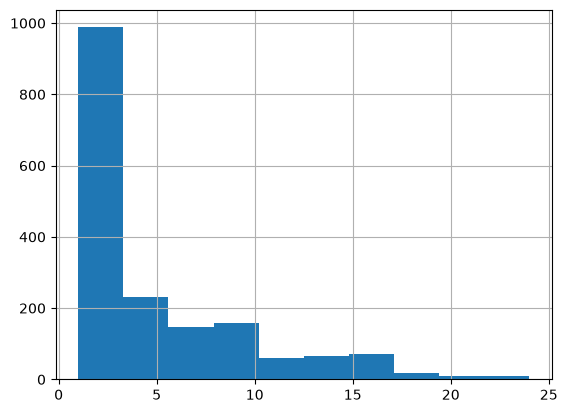

In [70]:
# Calcular el promedio usando solo los valores válidos (<=30)
promedio_piso = df.loc[df['piso_unidad'] <= 30, 'piso_unidad'].mean()

print(f"Promedio (excluyendo outliers): {promedio_piso:.2f}")
print(f"Registros a corregir: {(df['piso_unidad'] > 30).sum()}")

# Reemplazar los valores mayores a 30 por el promedio
df.loc[df['piso_unidad'] > 30, 'piso_unidad'] = promedio_piso

print(df.shape)
df["piso_unidad"].hist()
print(df.shape)


In [71]:
# Rellenamos los valores nulos de las columnas de cantidad de servicios con 0
vars = ["cantidad_paraderos", "cantidad_jardines_infantiles", "cantidad_colegios", 
    "cantidad_universidades", "cantidad_plazas", "cantidad_supermercados", 
    "cantidad_farmacias", "cantidad_centros_comerciales", "cantidad_hospitales", 
    "cantidad_clinicas", "cantidad_estaciones_metro", "estacionamientos"                  ]

df[vars] = df[vars].fillna(0)

In [72]:
# Eliminar registro si tiene nan en estas variables: dormitorios, baños, superficie_m2
df = df.dropna(subset=['dormitorios', 'banos', 'superficie_m2'])

In [73]:
RUTA_BD = "../01_obtener_datos/avisos_gran_concepcion.db"  # ajusta si tu notebook está en otra carpeta
API_UF_URL = "https://mindicador.cl/api/uf/{fecha}"


def inicializar_tabla_uf(con: sqlite3.Connection) -> None:
    con.execute("""
        CREATE TABLE IF NOT EXISTS valores_uf (
            fecha TEXT PRIMARY KEY,   -- formato YYYY-MM-DD
            valor REAL
        )
    """)
    con.commit()


def obtener_valores_uf_desde_bd(con: sqlite3.Connection, fechas: list) -> dict:
    """Devuelve {Timestamp: valor} solo para las fechas que YA están cacheadas en la BD."""
    if not fechas:
        return {}
    fechas_str = [f.strftime("%Y-%m-%d") for f in fechas]
    placeholders = ",".join("?" for _ in fechas_str)
    cur = con.execute(f"SELECT fecha, valor FROM valores_uf WHERE fecha IN ({placeholders})", fechas_str)
    return {pd.Timestamp(fecha): valor for fecha, valor in cur.fetchall()}


def guardar_valor_uf_en_bd(con: sqlite3.Connection, fecha: pd.Timestamp, valor: float) -> None:
    con.execute(
        "INSERT OR REPLACE INTO valores_uf (fecha, valor) VALUES (?, ?)",
        (fecha.strftime("%Y-%m-%d"), valor),
    )
    con.commit()  # commit inmediato por fecha, mismo criterio de guardado incremental que el resto del proyecto


def obtener_valor_uf_api(fecha: pd.Timestamp, reintentos: int = 3, espera: float = 1.0):
    """Consulta mindicador.cl. Devuelve None si no logra obtenerlo tras los reintentos."""
    fecha_str = fecha.strftime("%d-%m-%Y")
    url = API_UF_URL.format(fecha=fecha_str)

    for intento in range(reintentos):
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200:
                datos = resp.json()
                serie = datos.get("serie", [])
                if serie:
                    return serie[0]["valor"]
            return None
        except requests.RequestException:
            time.sleep(espera)

    return None


# ------------------------------------------------------------------
# Paso 0: asegurar que fecha_publicacion_aprox sea datetime
# ------------------------------------------------------------------
df["fecha_publicacion_aprox"] = pd.to_datetime(df["fecha_publicacion_aprox"], errors="coerce")

# ------------------------------------------------------------------
# Paso 1: fecha de respaldo = promedio de todas las fecha_publicacion_aprox
# ------------------------------------------------------------------
fecha_promedio = df["fecha_publicacion_aprox"].mean().normalize()
print(f"Fecha promedio usada como respaldo: {fecha_promedio.date()}")

# ------------------------------------------------------------------
# Paso 2: para cada fila en UF, determinar qué fecha usar
# ------------------------------------------------------------------
mask_uf = df["moneda"] == "UF"
fechas_a_usar = df.loc[mask_uf, "fecha_publicacion_aprox"].dt.normalize().fillna(fecha_promedio)

fechas_unicas = [pd.Timestamp(f) for f in fechas_a_usar.unique()]
fechas_a_verificar = list(set(fechas_unicas) | {fecha_promedio})  # incluye la de respaldo por si se necesita

# ------------------------------------------------------------------
# Paso 3: revisar primero la caché en la BD; solo consultar la API
# las fechas que falten ahí
# ------------------------------------------------------------------
con = sqlite3.connect(RUTA_BD)
inicializar_tabla_uf(con)

valor_uf_por_fecha = obtener_valores_uf_desde_bd(con, fechas_a_verificar)
print(f"{len(valor_uf_por_fecha)} valores de UF ya estaban en la base de datos (no se vuelve a consultar la API para esos).")

fechas_faltantes = [f for f in fechas_a_verificar if f not in valor_uf_por_fecha]
print(f"{len(fechas_faltantes)} fechas nuevas a consultar en mindicador.cl")

for fecha in fechas_faltantes:
    valor = obtener_valor_uf_api(fecha)
    if valor is not None:
        guardar_valor_uf_en_bd(con, fecha, valor)  # se guarda de inmediato para la próxima corrida
        valor_uf_por_fecha[fecha] = valor
    else:
        print(f"No se pudo obtener UF para {fecha.date()} tras varios intentos.")
    time.sleep(0.3)  # para no golpear la API de más

con.close()

# ------------------------------------------------------------------
# Paso 4: convertir a CLP (usa el valor de la fecha propia; si esa fecha
# específica no se pudo obtener, cae al valor ya resuelto de fecha_promedio)
# ------------------------------------------------------------------
df["precio_clp"] = df["precio"].astype(float)

for idx in df.index[mask_uf]:
    fecha = fechas_a_usar.loc[idx]
    valor_uf = valor_uf_por_fecha.get(fecha) or valor_uf_por_fecha.get(fecha_promedio)

    if valor_uf is not None:
        df.loc[idx, "precio_clp"] = df.loc[idx, "precio"] * valor_uf
    else:
        df.loc[idx, "precio_clp"] = None

print("Filas en UF sin conversión posible:", df.loc[mask_uf, "precio_clp"].isna().sum())

# Eliminar los registros con precio_clp mayor a 8 millones de pesos, ya que los mayores son venta
df = df[df["precio_clp"] <= 8000000]

Fecha promedio usada como respaldo: 2026-05-22
30 valores de UF ya estaban en la base de datos (no se vuelve a consultar la API para esos).
0 fechas nuevas a consultar en mindicador.cl
Filas en UF sin conversión posible: 0


In [74]:
import json
import numpy as np
import pandas as pd

N_CATEGORIAS = 5          # muy barato, barato, medio, alto, muy alto
K_SUAVIZADO = 20          # "avisos virtuales" del promedio general que se mezclan
                          # con el promedio de cada barrio (barrios chicos se
                          # acercan más al promedio general; barrios grandes casi no se ajustan)

NOMBRES_NIVELES = ["muy_barato", "barato", "medio", "alto", "muy_alto"]


def calcular_niveles_barrio(datos: pd.DataFrame, columna_precio_m2: str,
                             columna_barrio: str, n_categorias: int = N_CATEGORIAS,
                             k: float = K_SUAVIZADO):
    """
    Calcula el precio/m2 promedio SUAVIZADO de cada barrio (usando TODOS los
    datos disponibles) y los agrupa en `n_categorias` niveles ordinales,
    usando cuantiles PONDERADOS POR CANTIDAD DE AVISOS (no por cantidad de
    barrios) - así "alto" representa realmente ~20% de las propiedades más
    caras, no ~20% de los barrios sin importar cuántos avisos tenga cada uno.

    Devuelve:
      - mapa_barrio_a_nivel: dict {barrio: nivel_ordinal (0..n_categorias-1)}
      - nivel_default: nivel a usar para barrios nuevos que no existían al
        momento de construir este diccionario (útil para avisos futuros)
      - cortes_valor: los puntos de corte usados (para inspección/auditoría)
      - stats: tabla completa con el detalle de cada barrio (promedio crudo,
        cantidad de avisos, promedio ajustado, y nivel asignado)
    """
    promedio_general = datos[columna_precio_m2].mean()

    stats = datos.groupby(columna_barrio)[columna_precio_m2].agg(["mean", "count"])

    stats["promedio_ajustado"] = (
        (stats["count"] * stats["mean"] + k * promedio_general) / (stats["count"] + k)
    )

    stats_ordenado = stats.sort_values("promedio_ajustado")
    peso_acumulado = stats_ordenado["count"].cumsum() / stats_ordenado["count"].sum()

    limites_percentiles = np.linspace(0, 1, n_categorias + 1)[1:-1]
    cortes_valor = list(np.interp(
        limites_percentiles,
        peso_acumulado.values,
        stats_ordenado["promedio_ajustado"].values,
    ))

    def _clasificar(valor_ajustado):
        nivel = 0
        for corte in cortes_valor:
            if valor_ajustado > corte:
                nivel += 1
        return nivel

    stats["nivel"] = stats["promedio_ajustado"].apply(_clasificar)
    stats["nivel_nombre"] = stats["nivel"].map(lambda n: NOMBRES_NIVELES[n])

    mapa_barrio_a_nivel = stats["nivel"].to_dict()
    nivel_default = _clasificar(promedio_general)

    return mapa_barrio_a_nivel, nivel_default, cortes_valor, stats


def aplicar_niveles_barrio(datos: pd.DataFrame, columna_barrio: str,
                            mapa_barrio_a_nivel: dict, nivel_default: int) -> pd.Series:
    """Aplica el diccionario ya calculado a cualquier dataframe (actual o futuro),
    asignando `nivel_default` a cualquier barrio que no esté en el diccionario."""
    return (
        datos[columna_barrio]
        .map(mapa_barrio_a_nivel)
        .fillna(nivel_default)
        .astype(int)
    )


# ------------------------------------------------------------------
# Construir el diccionario con TODOS los datos disponibles
# ------------------------------------------------------------------

var_num= ["precio_clp", "superficie_util_m2"]
df[var_num] = df[var_num].apply(pd.to_numeric, errors="coerce")
df["_precio_m2"] = df["precio_clp"] / df["superficie_util_m2"].replace(0, np.nan)

mapa_barrio_a_nivel, nivel_default, cortes_valor, stats_barrios = calcular_niveles_barrio(
    df, columna_precio_m2="_precio_m2", columna_barrio="barrio"
)

df = df.drop(columns=["_precio_m2"])

print("Cortes de precio/m2 usados para los 5 niveles:")
for i, corte in enumerate(cortes_valor):
    print(f"  {NOMBRES_NIVELES[i]} / {NOMBRES_NIVELES[i+1]}: ${corte:,.0f}")

print(f"\nNivel por defecto para barrios nuevos/no vistos: {nivel_default} ({NOMBRES_NIVELES[nivel_default]})")

print("\nDetalle completo por barrio:")
print(stats_barrios.sort_values("promedio_ajustado", ascending=False).to_string())

# ------------------------------------------------------------------
# Aplicar de inmediato a tus datos actuales
# ------------------------------------------------------------------
df["nivel_barrio"] = aplicar_niveles_barrio(df, "barrio", mapa_barrio_a_nivel, nivel_default)
df.drop("barrio", axis=1, inplace=True)

Cortes de precio/m2 usados para los 5 niveles:
  muy_barato / barato: $11,776
  barato / medio: $12,381
  medio / alto: $13,847
  alto / muy_alto: $17,713

Nivel por defecto para barrios nuevos/no vistos: 3 (alto)

Detalle completo por barrio:
                                                   mean  count  promedio_ajustado  nivel nivel_nombre
barrio                                                                                               
Carriel                                   126694.975232     28       80665.835198      4     muy_alto
Bajo Tucapel                               59626.322536     10       30692.133613      4     muy_alto
Portal San Pedro                           25474.657958     94       23851.917817      4     muy_alto
Lorenzo Arenas                             21273.784882     45       19720.324657      4     muy_alto
Lomas de San Sebastián                     20294.649067     86       19526.798140      4     muy_alto
Brisas del Sol                            

In [75]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

UMBRAL_MINIMO_M2 = 30
COLUMNAS_PREDICTORAS = ["dormitorios", "banos", "comuna"]
MINIMO_FILAS_PARA_ENTRENAR = 20

RUTA_MODELOS = Path("modelos_superficie")


def estimar_superficie(df: pd.DataFrame, columna_objetivo: str,
                        columnas_predictoras: list = COLUMNAS_PREDICTORAS,
                        umbral_minimo: float = UMBRAL_MINIMO_M2,
                        columna_agrupacion: str = "tipo_propiedad") -> pd.Series:
    """
    Entrena UN MODELO SEPARADO por cada valor de `columna_agrupacion` (por
    defecto, uno para 'casa' y otro para 'departamento'), usando SOLO las
    filas con `columna_objetivo` >= umbral_minimo como datos confiables, y
    estima el valor para las filas con valor < umbral_minimo o NaN.

    El modelo FINAL de cada grupo se entrena con el 100% de los datos
    confiables de ese grupo (no solo el 80% usado para la validación), y se
    guarda en un .pkl (junto con la lista de columnas que espera como input)
    para poder reutilizarlo en producción sin tener que reentrenar.

    Devuelve la columna ya corregida (float).
    """
    resultado = df[columna_objetivo].astype(float).copy()

    es_confiable = resultado.notna() & (resultado >= umbral_minimo)
    necesita_estimacion = ~es_confiable

    print(f"\n--- {columna_objetivo} ---")

    for valor_grupo, indices_grupo in df.groupby(columna_agrupacion).groups.items():
        indices_grupo = pd.Index(indices_grupo)

        conf_grupo = es_confiable.loc[indices_grupo]
        est_grupo = necesita_estimacion.loc[indices_grupo]

        print(f"[{columna_agrupacion}='{valor_grupo}'] confiables: {conf_grupo.sum()} | a estimar: {est_grupo.sum()}")

        if conf_grupo.sum() < MINIMO_FILAS_PARA_ENTRENAR:
            print(f"  Advertencia: solo {conf_grupo.sum()} filas confiables, muy pocas para entrenar "
                  f"un modelo separado de '{valor_grupo}'. Se omite (no se guarda modelo, esas filas quedan sin estimar).")
            continue

        X_grupo = df.loc[indices_grupo, columnas_predictoras]
        columnas_categoricas = X_grupo.select_dtypes(include=["object", "category", "str"]).columns.tolist()
        X_grupo = pd.get_dummies(X_grupo, columns=columnas_categoricas, drop_first=True)

        X_train_full = X_grupo[conf_grupo]
        y_train_full = resultado.loc[indices_grupo][conf_grupo]

        # --- Validación rápida (solo para reportar qué tan confiable es) ---
        X_tr, X_val, y_tr, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

        modelo_val = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        modelo_val.fit(X_tr, y_tr)
        pred_val = modelo_val.predict(X_val)

        mae_val = mean_absolute_error(y_val, pred_val)
        r2_val = r2_score(y_val, pred_val)
        print(f"  Validación (20% hold-out): MAE=±{mae_val:.1f} m2 | R²={r2_val:.3f}")

        # --- Modelo FINAL: entrenado con el 100% de los datos confiables del grupo ---
        modelo_final = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
        modelo_final.fit(X_train_full, y_train_full)

        # --- Aplicar la estimación a las filas que la necesitan (si hay) ---
        if est_grupo.sum() == 0:
            print("  Nada que estimar en este grupo (pero el modelo se guardó igual para uso futuro).")
            continue

        X_a_estimar = X_grupo[est_grupo]
        estimaciones = np.round(modelo_final.predict(X_a_estimar), 1)
        resultado.loc[X_a_estimar.index] = estimaciones

        print(f"  Rango estimado: {estimaciones.min():.1f} - {estimaciones.max():.1f} m2")

    return resultado


def aplicar_modelo_guardado(df_nuevo: pd.DataFrame, columna_objetivo: str, grupo: str,
                             columna_agrupacion: str = "tipo_propiedad") -> np.ndarray:
    """
    Carga un modelo ya entrenado y guardado (.pkl) y lo aplica a datos nuevos
    en producción. `df_nuevo` debe tener las mismas columnas originales
    (dormitorios, banos, comuna, etc.) que se usaron al entrenar.
    """
    nombre_archivo = RUTA_MODELOS / f"modelo_{columna_objetivo}_{grupo}.pkl"
    paquete = joblib.load(nombre_archivo)

    X_nuevo = df_nuevo[paquete["columnas_predictoras_originales"]]
    columnas_categoricas = X_nuevo.select_dtypes(include=["object", "category", "str"]).columns.tolist()
    X_nuevo = pd.get_dummies(X_nuevo, columns=columnas_categoricas, drop_first=True)

    # Alinear columnas exactamente como en entrenamiento (agrega con 0 las que
    # falten - ej. una comuna que no apareció en este lote nuevo - y descarta
    # cualquier columna nueva que el modelo no conozca)
    X_nuevo = X_nuevo.reindex(columns=paquete["columnas_entrenamiento"], fill_value=0)

    return paquete["modelo"].predict(X_nuevo)


# ------------------------------------------------------------------
# Aplicar por separado a superficie_util_m2 y superficie_total_m2.
# Para superficie_total_m2 se agrega superficie_util_m2 como predictor
# adicional (ya viene corregida del paso anterior).
# ------------------------------------------------------------------


var_num = ["superficie_util_m2", "superficie_total_m2"]
df[var_num] = df[var_num].apply(pd.to_numeric, errors="coerce")

df["superficie_util_m2"] = estimar_superficie(df, "superficie_util_m2")
df["superficie_total_m2"] = estimar_superficie(
    df, "superficie_total_m2",
    columnas_predictoras=COLUMNAS_PREDICTORAS + ["superficie_util_m2"],
)


--- superficie_util_m2 ---
[tipo_propiedad='casa'] confiables: 241 | a estimar: 15
  Validación (20% hold-out): MAE=±51.7 m2 | R²=0.539
  Modelo guardado en: modelos_superficie\modelo_superficie_util_m2_casa.pkl
  Rango estimado: 41.6 - 315.4 m2
[tipo_propiedad='departamento'] confiables: 1243 | a estimar: 233
  Validación (20% hold-out): MAE=±7.7 m2 | R²=0.631
  Modelo guardado en: modelos_superficie\modelo_superficie_util_m2_departamento.pkl
  Rango estimado: 34.1 - 128.0 m2

--- superficie_total_m2 ---
[tipo_propiedad='casa'] confiables: 230 | a estimar: 26
  Validación (20% hold-out): MAE=±82.3 m2 | R²=0.461
  Modelo guardado en: modelos_superficie\modelo_superficie_total_m2_casa.pkl
  Rango estimado: 61.7 - 635.2 m2
[tipo_propiedad='departamento'] confiables: 1253 | a estimar: 223
  Validación (20% hold-out): MAE=±2.9 m2 | R²=0.927
  Modelo guardado en: modelos_superficie\modelo_superficie_total_m2_departamento.pkl
  Rango estimado: 30.9 - 120.9 m2


In [76]:
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

RADIO_METROS = 300
RADIO_TIERRA_M = 6371000

TIPOS_PROPIEDAD_COLUMNAS = {
    "casa": "precio_m2_sector_casa",
    "departamento": "precio_m2_sector_departamento",
}

MULTIPLICADOR_IQR = 3


def limites_iqr(serie, multiplicador: float = MULTIPLICADOR_IQR):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - multiplicador * iqr, q3 + multiplicador * iqr


# ------------------------------------------------------------------
# precio_m2 SOLO se usa acá, como variable auxiliar interna, para calcular
# los promedios de sector - NO se guarda en df ni se usa como feature del
# modelo (ese fue el error anterior: usarla directo sí es fuga de datos,
# porque viene del precio de la propia fila).
# ------------------------------------------------------------------
precio_m2_auxiliar = df["precio_clp"] / df["superficie_util_m2"].replace(0, np.nan)

for columna in TIPOS_PROPIEDAD_COLUMNAS.values():
    df[columna] = np.nan  # se rellena con el fallback más abajo si no hay vecinos

df["tiene_comparables_cercanos"] = False  # transparencia: distingue "sin vecinos" de "vecino real en 0"

radio_rad = RADIO_METROS / RADIO_TIERRA_M

for tipo, indices_grupo in df.groupby("tipo_propiedad").groups.items():
    columna_destino = TIPOS_PROPIEDAD_COLUMNAS.get(tipo)
    if columna_destino is None:
        continue

    indices_grupo = pd.Index(indices_grupo)
    precio_m2_grupo = precio_m2_auxiliar.loc[indices_grupo]

    tiene_coords = df.loc[indices_grupo, ["latitud", "longitud"]].notna().all(axis=1)
    tiene_precio_m2 = precio_m2_grupo.notna()

    lim_inf, lim_sup = limites_iqr(precio_m2_grupo[tiene_precio_m2])
    es_razonable = precio_m2_grupo.between(lim_inf, lim_sup)

    print(f"[{tipo}] rango razonable de precio_m2: ${lim_inf:,.0f} - ${lim_sup:,.0f} "
          f"({(tiene_precio_m2 & ~es_razonable).sum()} filas excluidas por outlier)")

    idx_validos = indices_grupo[tiene_coords & tiene_precio_m2 & es_razonable]
    mediana_general_grupo = precio_m2_grupo[idx_validos].median()  # fallback si no hay vecinos

    if len(idx_validos) < 2:
        df.loc[indices_grupo, columna_destino] = mediana_general_grupo
        continue

    coords = np.radians(df.loc[idx_validos, ["latitud", "longitud"]].astype(float).values)
    precios_m2 = precio_m2_grupo.loc[idx_validos].values

    arbol = BallTree(coords, metric="haversine")
    vecinos_por_fila = arbol.query_radius(coords, r=radio_rad)

    for pos, idx_fila in enumerate(idx_validos):
        vecinos_idx = vecinos_por_fila[pos]
        vecinos_sin_si_mismo = vecinos_idx[vecinos_idx != pos]

        if len(vecinos_sin_si_mismo) == 0:
            df.loc[idx_fila, columna_destino] = mediana_general_grupo
        else:
            df.loc[idx_fila, columna_destino] = np.median(precios_m2[vecinos_sin_si_mismo])
            df.loc[idx_fila, "tiene_comparables_cercanos"] = True

    # Filas sin coords / sin precio_m2 válido / outlier: también caen al fallback general
    idx_resto = indices_grupo.difference(idx_validos)
    df.loc[idx_resto, columna_destino] = mediana_general_grupo

    # Las filas del OTRO tipo de propiedad nunca pasaron por este bloque, así
    # que su valor en esta columna sigue en NaN - se rellenan con el mismo
    # fallback general (ej. 'precio_m2_sector_casa' para una fila que es
    # departamento queda en la mediana general de las casas del dataset).
    df[columna_destino] = df[columna_destino].fillna(mediana_general_grupo)

print()
print(df[[
    "tipo_propiedad", "precio_m2_sector_casa", "precio_m2_sector_departamento", "tiene_comparables_cercanos",
]].describe(include="all"))

[casa] rango razonable de precio_m2: $-5,175 - $21,284 (2 filas excluidas por outlier)
[departamento] rango razonable de precio_m2: $714 - $19,881 (4 filas excluidas por outlier)

       tipo_propiedad  precio_m2_sector_casa  precio_m2_sector_departamento tiene_comparables_cercanos
count            1732            1732.000000                    1732.000000                       1732
unique              2                    NaN                            NaN                          2
top      departamento                    NaN                            NaN                       True
freq             1476                    NaN                            NaN                       1591
mean              NaN            7842.148198                   10285.783069                        NaN
std               NaN             744.123434                    1050.467851                        NaN
min               NaN            3865.101875                    4606.741573                        

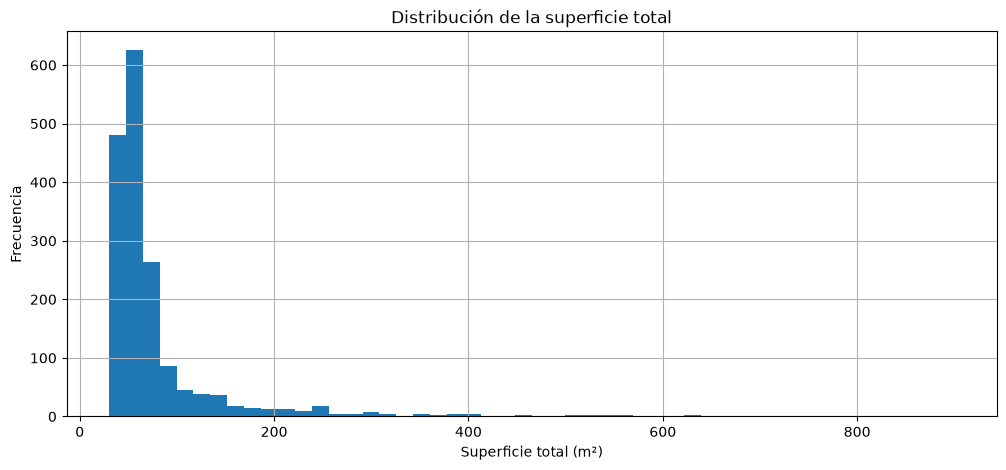

In [77]:
import matplotlib.pyplot as plt

var_num= ["superficie_total_m2"]
df[var_num] = df[var_num].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(12, 5))  # (ancho, alto) en pulgadas
df["superficie_total_m2"].hist(bins=50)

plt.xlabel("Superficie total (m²)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la superficie total")
plt.show()

In [78]:
df.drop(["precio", "moneda"], axis=1, inplace=True)

In [79]:
"""  
Para las columnas de antiguedad_anos, condominio_cerrado en donde haya nan, rellenar buscando 
en la misma base, los valores que tienen otros registros con la misma latitud y longitud. 
Si no hay registros con la misma latitud y longitud, mantener con nan.                           

"""

df['antiguedad_anos'] = df.groupby(['latitud', 'longitud'])['antiguedad_anos'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
df['condominio_cerrado'] = df.groupby(['latitud', 'longitud'])['condominio_cerrado'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

# Para el resto de nan en condominio_cerrado, rellenar con "No"
df['condominio_cerrado'] = df['condominio_cerrado'].fillna('No')

In [80]:
df["condominio_cerrado"].value_counts()

condominio_cerrado
Sí    1194
No     538
Name: count, dtype: int64

In [81]:
RADIO_METROS = 200
RADIO_TIERRA_M = 6371000

# ------------------------------------------------------------------
# Paso 0: conversión de tipos (vienen como TEXT desde SQLite)
# ------------------------------------------------------------------
df["antiguedad_anos"] = pd.to_numeric(df["antiguedad_anos"], errors="coerce")
df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")

# ------------------------------------------------------------------
# Función de imputación por cercanía (200m, mismo tipo_propiedad)
# ------------------------------------------------------------------
def imputar_por_cercania_200m(df, columna="antiguedad_anos", radio_metros=RADIO_METROS):
    """
    Para cada fila con NaN en `columna`, busca otras filas del mismo
    tipo_propiedad dentro de `radio_metros` (usando latitud/longitud) y
    devuelve la mediana de esos vecinos. Si no hay vecinos, deja el NaN
    (se resuelve en los fallbacks siguientes).
    """
    valores_originales = df[columna].copy()
    resultado = valores_originales.copy()
    radio_rad = radio_metros / RADIO_TIERRA_M

    for _, grupo in df.groupby("tipo_propiedad"):
        tiene_coords = grupo[["latitud", "longitud"]].notna().all(axis=1)
        tiene_valor = valores_originales.loc[grupo.index].notna()

        idx_con_dato = grupo.index[tiene_valor & tiene_coords]
        idx_sin_dato = grupo.index[~tiene_valor & tiene_coords]  # sin coords no se puede buscar vecinos

        if len(idx_con_dato) == 0 or len(idx_sin_dato) == 0:
            continue

        coords_con_dato = np.radians(
            grupo.loc[idx_con_dato, ["latitud", "longitud"]].astype(float).values
        )
        coords_sin_dato = np.radians(
            grupo.loc[idx_sin_dato, ["latitud", "longitud"]].astype(float).values
        )

        arbol = BallTree(coords_con_dato, metric="haversine")
        vecinos_por_fila = arbol.query_radius(coords_sin_dato, r=radio_rad)

        for idx_fila, vecinos in zip(idx_sin_dato, vecinos_por_fila):
            if len(vecinos) > 0:
                valores_vecinos = valores_originales.loc[idx_con_dato].iloc[vecinos]
                resultado.loc[idx_fila] = valores_vecinos.median()

    return resultado


# ------------------------------------------------------------------
# Guardamos los valores originales ANTES de imputar nada.
# Todos los fallbacks se calculan sobre estos valores originales, nunca
# sobre resultados ya imputados en un paso anterior (para no contaminar
# las medianas con estimaciones previas).
# ------------------------------------------------------------------
valores_originales = df["antiguedad_anos"].copy()

# Paso 1: vecinos dentro de 200m, mismo tipo_propiedad
df["antiguedad_anos"] = imputar_por_cercania_200m(df, "antiguedad_anos", RADIO_METROS)

# Paso 2: mediana por tipo_propiedad (calculada desde los datos ORIGINALES)
mediana_por_tipo = df.groupby("tipo_propiedad")["tipo_propiedad"].transform(
    lambda serie: valores_originales.loc[serie.index].median()
)
df["antiguedad_anos"] = df["antiguedad_anos"].fillna(mediana_por_tipo)

# Paso 3: mediana por comuna (calculada desde los datos ORIGINALES)
mediana_por_comuna = df.groupby("comuna")["comuna"].transform(
    lambda serie: valores_originales.loc[serie.index].median()
)
df["antiguedad_anos"] = df["antiguedad_anos"].fillna(mediana_por_comuna)

# Paso 4: mediana global (también desde los datos ORIGINALES)
df["antiguedad_anos"] = df["antiguedad_anos"].fillna(valores_originales.median())

# ------------------------------------------------------------------
# Paso 5: convertir a entero, solo ahora que ya no debería quedar ningún NaN
# ------------------------------------------------------------------
print("NaN restantes antes de convertir:", df["antiguedad_anos"].isna().sum())  # debería ser 0
df["antiguedad_anos"] = df["antiguedad_anos"].round().astype("Int64")

NaN restantes antes de convertir: 0


In [82]:
df.drop(columns=['latitud', 'longitud', "fecha_publicacion_aprox", 
       #          "id_aviso"
                 ], inplace=True)

In [83]:
# Transformar la columna tipo_propiedad en variables dummy (one-hot encoding), eliminar la columna original y dejar solo la columnas de casas
df = pd.get_dummies(df, columns=["tipo_propiedad"], prefix="tipo_propiedad", drop_first=True)

In [84]:
# Transformar a variables numéricas las columnas de dormitorios, baños, superficie_m2 y estacionamientos.
vars = ["dormitorios", "banos", "superficie_m2", "estacionamientos"]

df[vars] = df[vars].apply(pd.to_numeric, errors="coerce")

In [85]:
COMUNAS_A_AGRUPAR = [
    "talcahuano-biobio",
    "chiguayante-biobio",
    "hualpen-biobio",
    "coronel-biobio",
    "tome-biobio",
    "penco-biobio",
    "hualqui-biobio",
]

df.loc[df["comuna"].isin(COMUNAS_A_AGRUPAR), "comuna"] = "otras comunas"

In [86]:
# Comunas convertidas a variables dummy (one-hot encoding), eliminando la columna original y 
# dejando solo las columnas de comunas.
df = pd.get_dummies(df, columns=["comuna"], prefix="comuna", drop_first=True)

In [87]:
# Cubre las variantes más comunes: amoblado/amoblada, amueblado/amueblada,
# y también sin tilde por si algún título viene mal escrito.
PATRON_AMOBLADO = re.compile(r"amoblad[oa]|amueblad[oa]", re.IGNORECASE)

df["amoblado"] = df["titulo"].str.contains(PATRON_AMOBLADO, na=False).astype(int)
df.drop(columns=["titulo"], inplace=True)

In [88]:
# si "superficie_total_m2" o "superficie_util_m2" es nan, rellenar con "superficie_m2"
df["superficie_total_m2"] = df["superficie_total_m2"].fillna(df["superficie_m2"])
df["superficie_util_m2"] = df["superficie_util_m2"].fillna(df["superficie_m2"])
# Transformar a numérico las columnas de superficie_total_m2 y superficie_util_m2
df[["superficie_total_m2", "superficie_util_m2"]] = df[["superficie_total_m2", "superficie_util_m2"]].apply(pd.to_numeric, errors="coerce")

df.dropna(subset=["superficie_total_m2", "superficie_util_m2"], inplace=True)
df.drop(columns=["superficie_m2"], inplace=True)

In [89]:
# Si  "condominio_cerrado" son si, dejar como true, si dicen no, dejar como false. 
# Cambiar el tipo de dato a booleano.

df["condominio_cerrado"] = df["condominio_cerrado"].str.lower().map({"sí": True, "no": False})

In [90]:
# Ratio de m2 utiles 

df["ratio_total_util"] = (
    df["superficie_total_m2"] / df["superficie_util_m2"].replace(0, float("nan"))
)

# Eliminar m2 totales

#df.drop("superficie_total_m2", inplace=True, axis=1)

#### EDA

In [91]:
df.isnull().sum()

id_aviso                             0
banos                                0
estacionamientos                     0
dormitorios                          0
antiguedad_anos                      0
condominio_cerrado                   0
distancia_centro_comuna_m            0
distancia_centro_concepcion_m        0
cantidad_paraderos                   0
cantidad_jardines_infantiles         0
cantidad_colegios                    0
cantidad_universidades               0
cantidad_plazas                      0
cantidad_supermercados               0
cantidad_farmacias                   0
cantidad_centros_comerciales         0
cantidad_hospitales                  0
cantidad_clinicas                    0
cantidad_estaciones_metro            0
superficie_total_m2                  0
superficie_util_m2                   0
bodegas                              0
gastos_comunes                       0
estacionamiento_visitas              0
piscina                              0
quincho                  

In [92]:
df.drop("id_aviso", axis=1, inplace=True)

RESUMEN GENERAL
Filas: 1732 | Columnas: 45

banos                                float64
estacionamientos                     float64
dormitorios                            int64
antiguedad_anos                        Int64
condominio_cerrado                      bool
distancia_centro_comuna_m            float64
distancia_centro_concepcion_m        float64
cantidad_paraderos                   float64
cantidad_jardines_infantiles         float64
cantidad_colegios                    float64
cantidad_universidades               float64
cantidad_plazas                      float64
cantidad_supermercados               float64
cantidad_farmacias                   float64
cantidad_centros_comerciales         float64
cantidad_hospitales                  float64
cantidad_clinicas                    float64
cantidad_estaciones_metro            float64
superficie_total_m2                  float64
superficie_util_m2                   float64
bodegas                              float64
gastos_comu

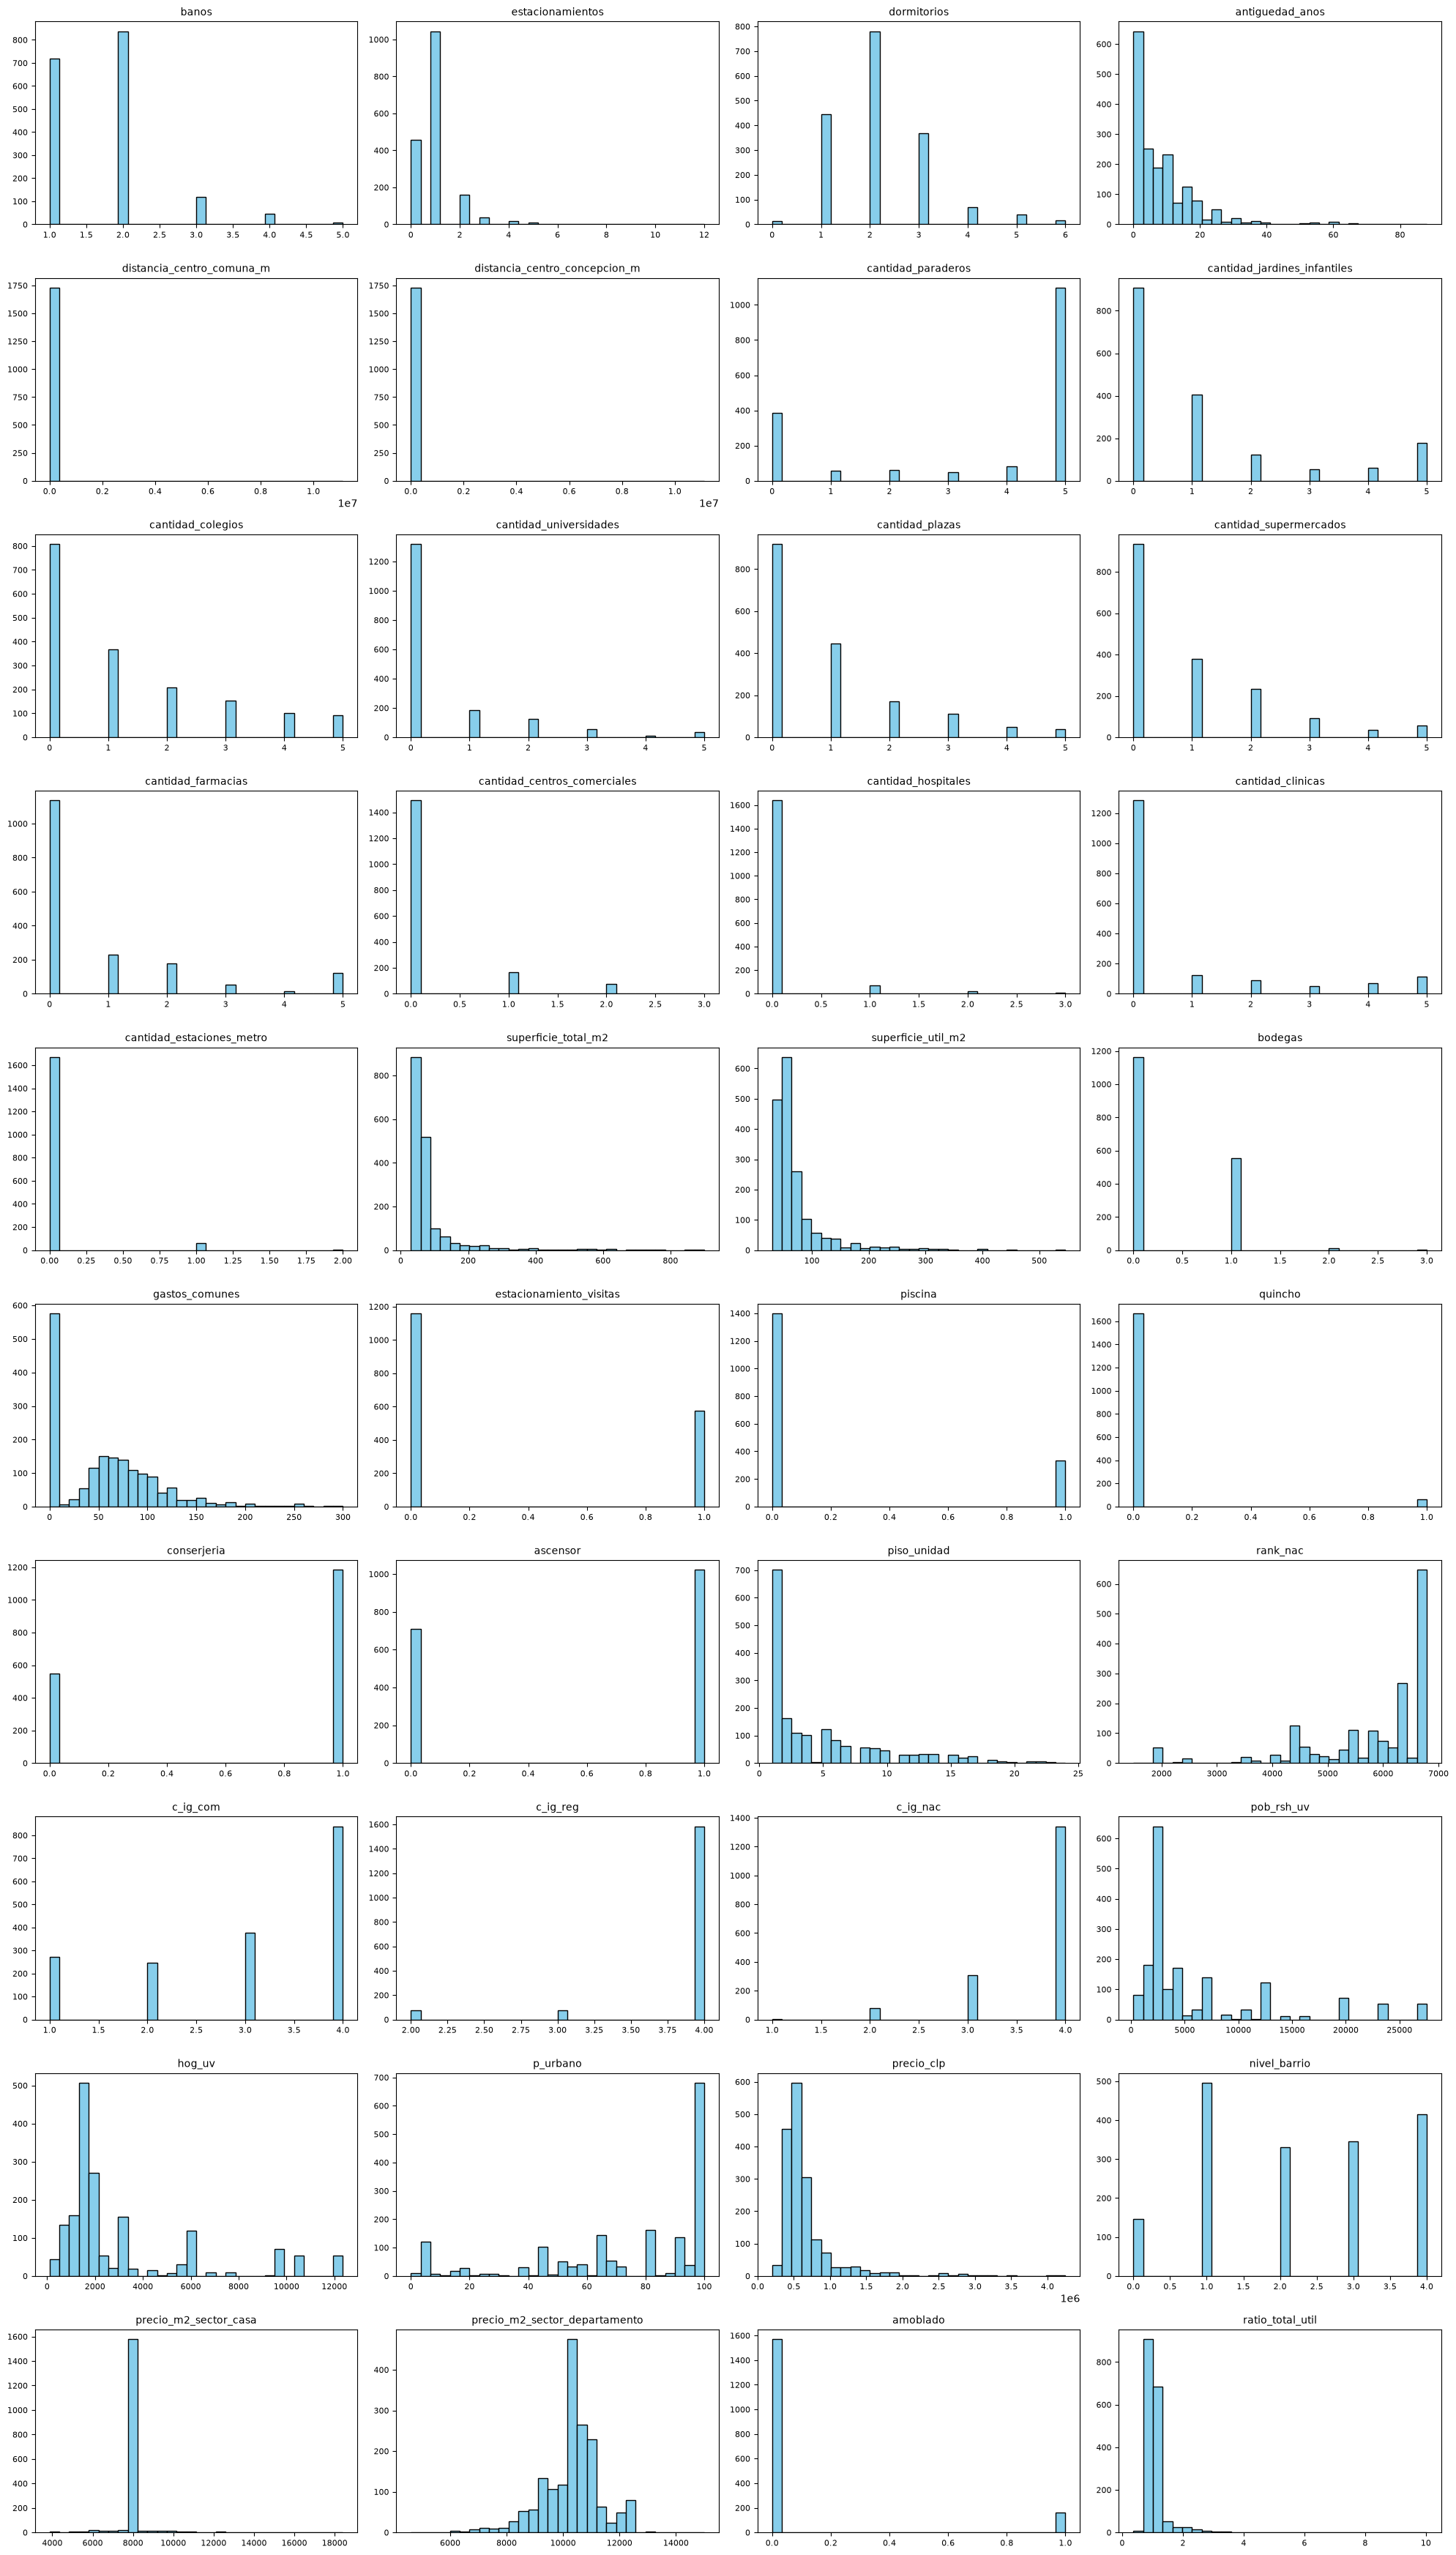

C:\Users\felip\AppData\Local\Temp\ipykernel_19912\116955588.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\felip\AppData\Local\Temp\ipykernel_19912\116955588.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\felip\AppData\Local\Temp\ipykernel_19912\116955588.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\felip\AppData\Local\Temp\ipykernel_19912\116955588.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientati

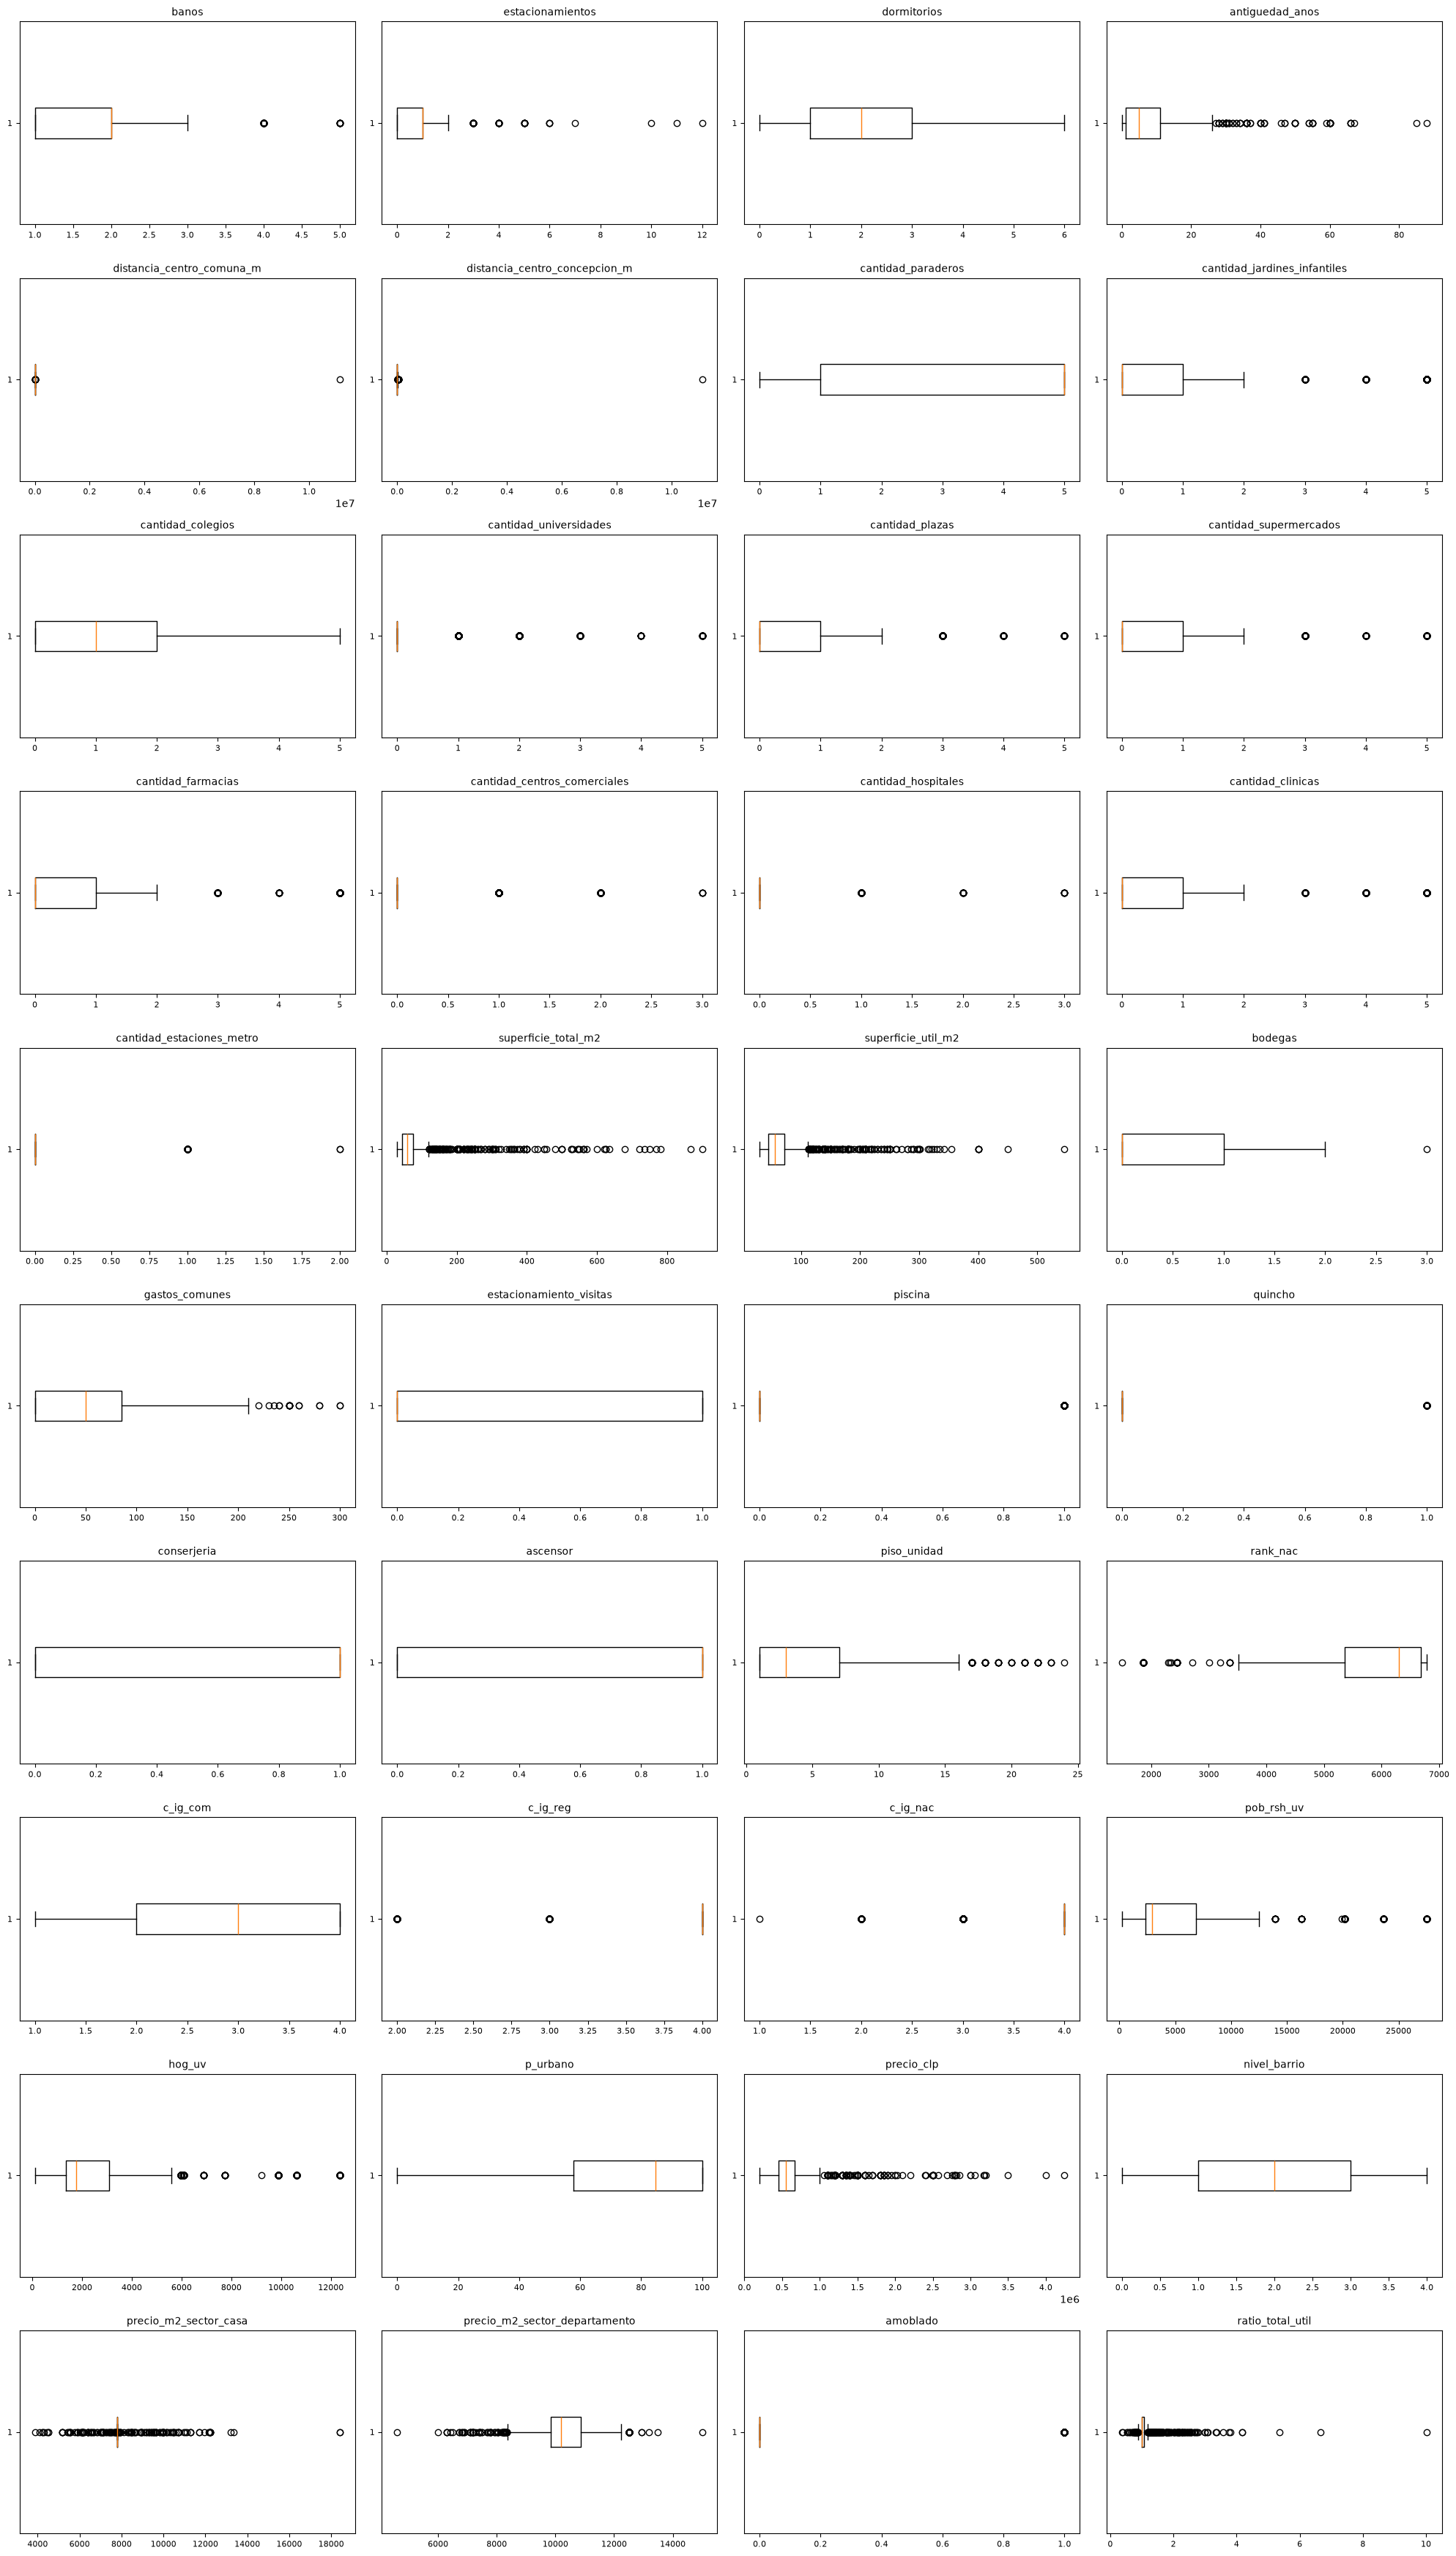


COLUMNAS CATEGÓRICAS (0)

MATRIZ DE CORRELACIÓN


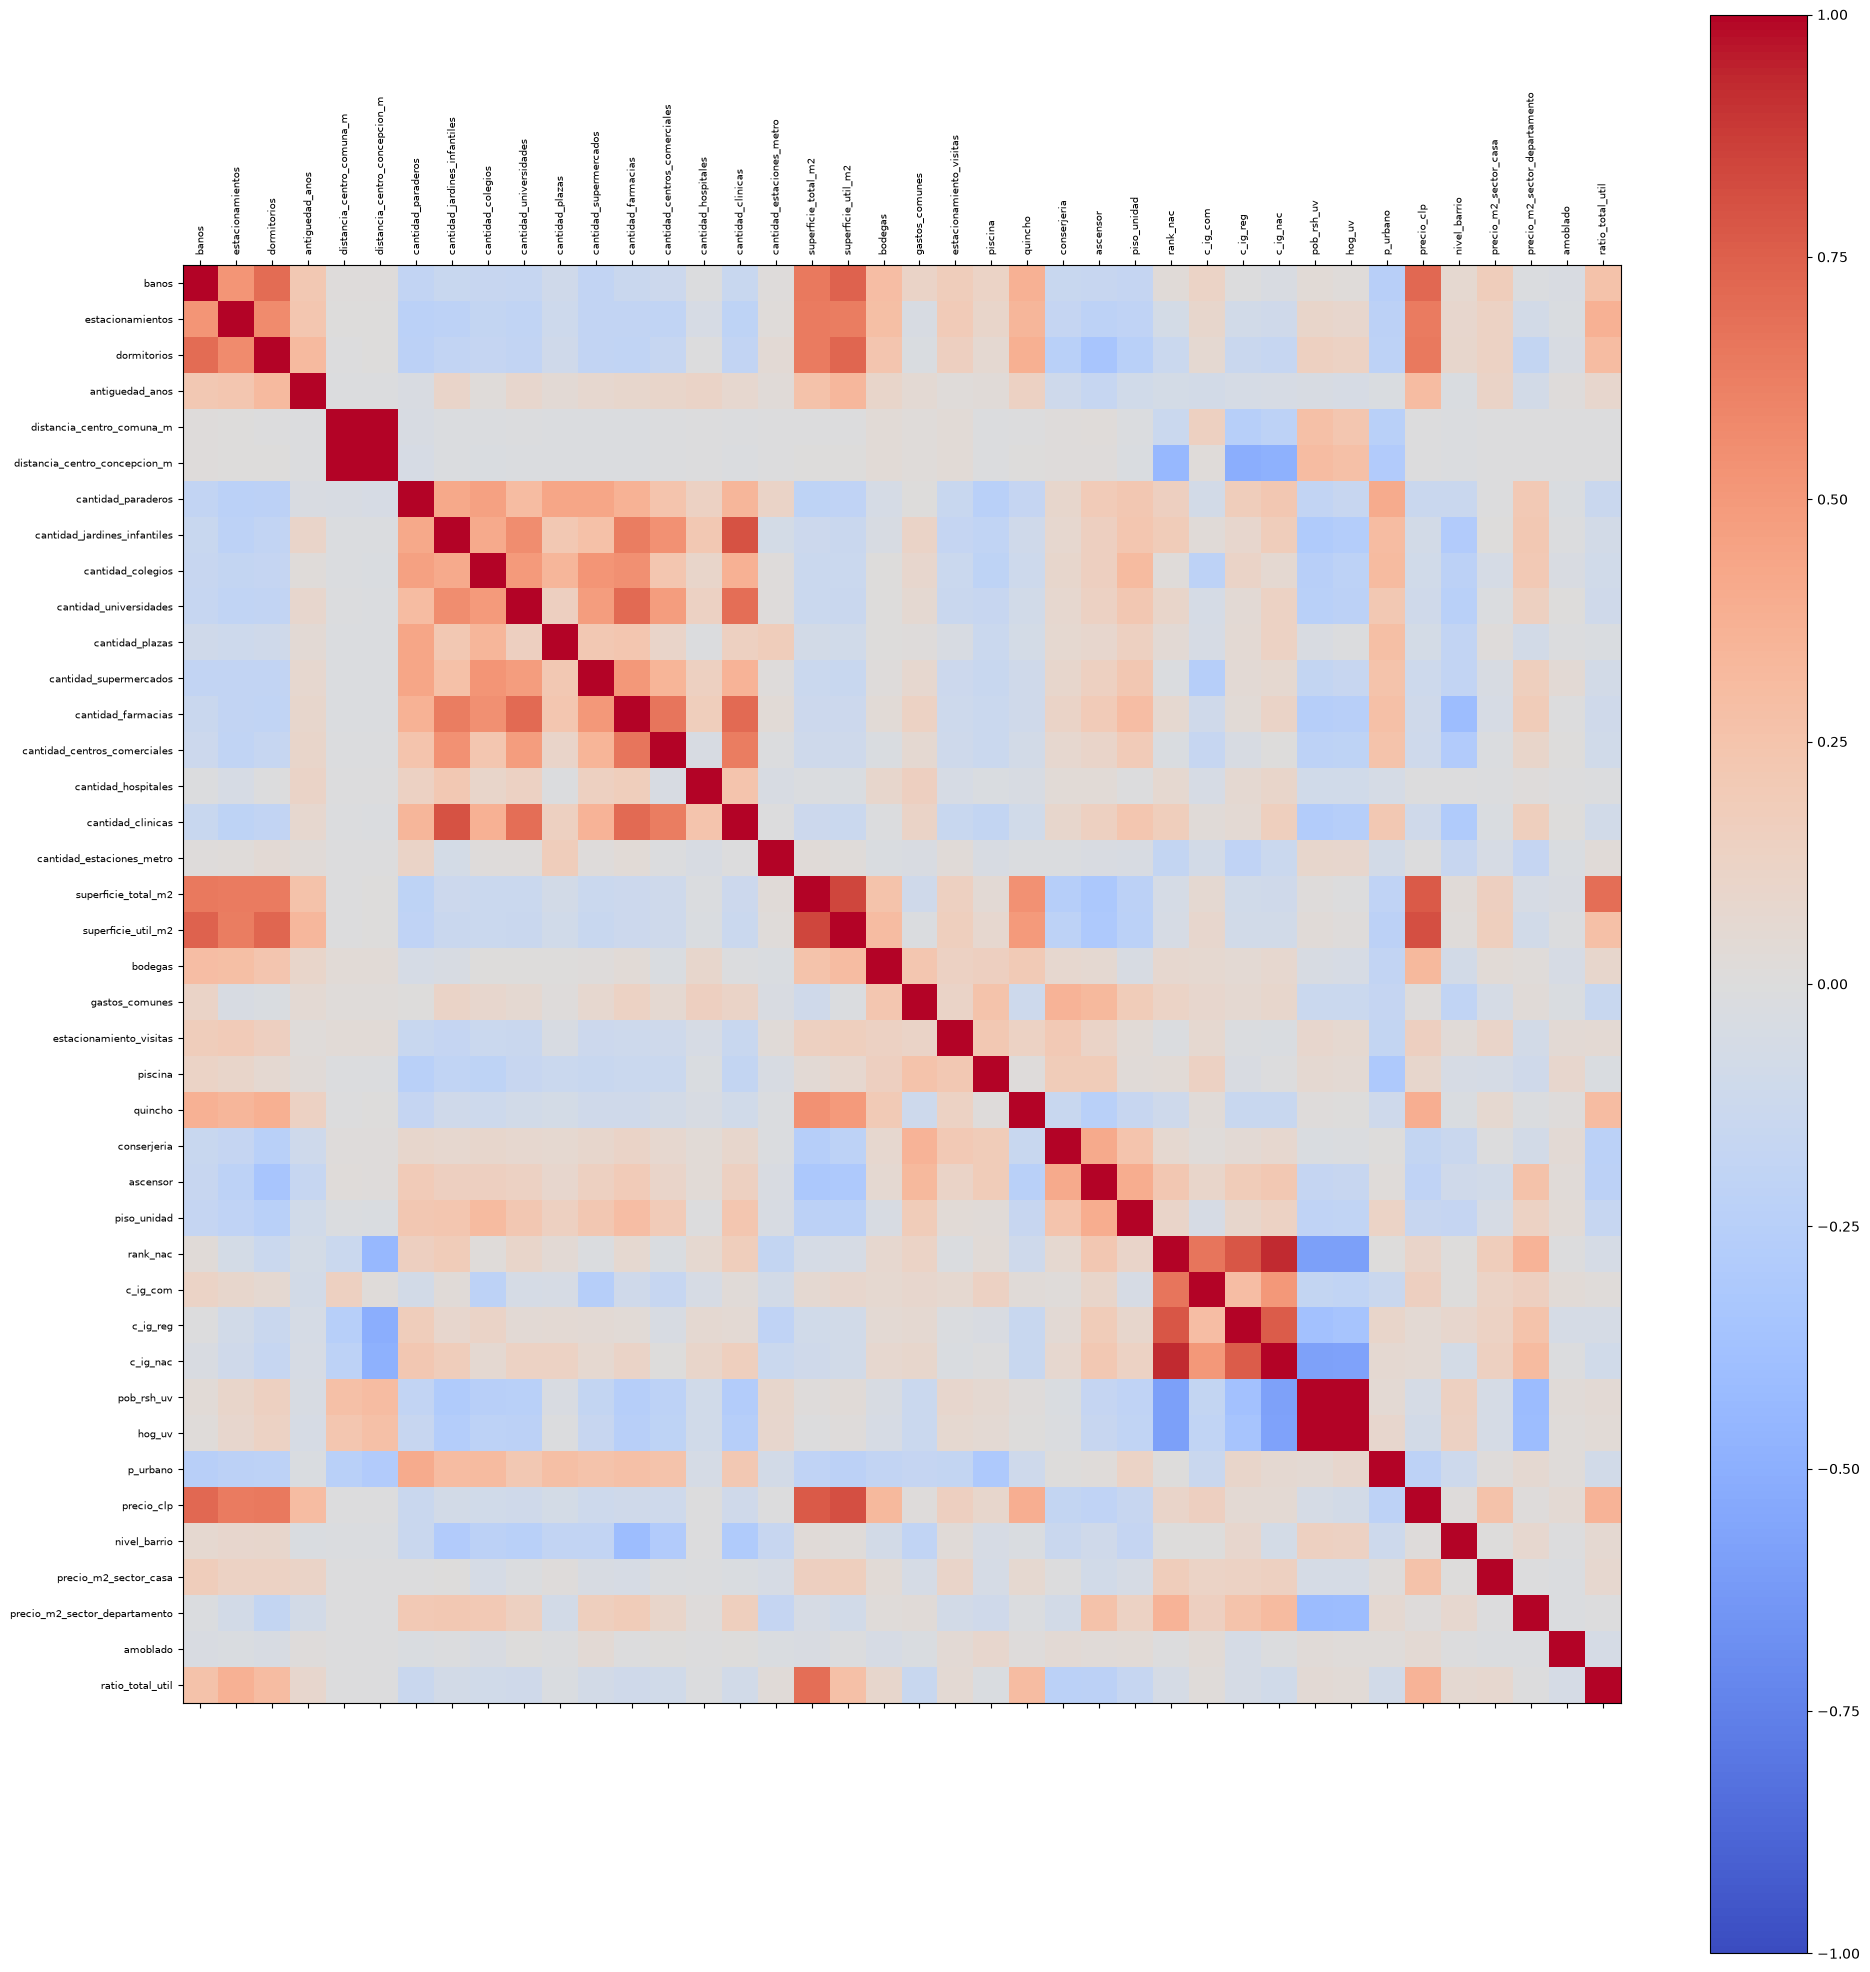

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ------------------------------------------------------------------
# 1. Resumen general
# ------------------------------------------------------------------
print("=" * 70)
print("RESUMEN GENERAL")
print("=" * 70)
print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
print()
print(df.dtypes)

# ------------------------------------------------------------------
# 2. Valores faltantes por columna
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("VALORES FALTANTES")
print("=" * 70)
faltantes = df.isna().sum()
faltantes_pct = (faltantes / len(df) * 100).round(1)
resumen_faltantes = pd.DataFrame({"cantidad": faltantes, "porcentaje": faltantes_pct})
print(resumen_faltantes[resumen_faltantes["cantidad"] > 0].sort_values("cantidad", ascending=False))

# ------------------------------------------------------------------
# 3. Estadísticas descriptivas - numéricas
# ------------------------------------------------------------------
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "category", "str"]).columns.tolist()

print("\n" + "=" * 70)
print(f"ESTADÍSTICAS DESCRIPTIVAS ({len(columnas_numericas)} columnas numéricas)")
print("=" * 70)
print(df[columnas_numericas].describe().T)

# ------------------------------------------------------------------
# 4. Histogramas de todas las columnas numéricas (rangos y distribución)
# ------------------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(columnas_numericas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Ocultar los subplots sobrantes si columnas no llena la grilla completa
for j in range(len(columnas_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Boxplots - buenos para ver rangos y outliers de un vistazo
# ------------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(len(columnas_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6. Columnas categóricas: conteo de valores
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"COLUMNAS CATEGÓRICAS ({len(columnas_categoricas)})")
print("=" * 70)
for col in columnas_categoricas:
    print(f"\n--- {col} ({df[col].nunique()} valores únicos) ---")
    print(df[col].value_counts().head(15))

# ------------------------------------------------------------------
# 7. Matriz de correlación (solo numéricas)
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("MATRIZ DE CORRELACIÓN")
print("=" * 70)

correlacion = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(min(0.5 * len(columnas_numericas), 20), min(0.5 * len(columnas_numericas), 20)))
cax = ax.matshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_numericas)))
ax.set_yticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=90, fontsize=7)
ax.set_yticklabels(columnas_numericas, fontsize=7)
fig.colorbar(cax)
plt.tight_layout()
plt.show()

#### Modelo prelimimar de prueba

In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------------
# Separar variable objetivo (y) del resto de columnas (X)
# ------------------------------------------------------------------
y = df["precio_clp"]
X = df.drop(columns=["precio_clp"])

# ------------------------------------------------------------------
# Codificar columnas categóricas (texto) a variables dummy (0/1).
# Random Forest no puede recibir texto directamente.
# ------------------------------------------------------------------
columnas_categoricas = X.select_dtypes(include=["object", "category", "str"]).columns.tolist()
print(f"Columnas categóricas detectadas y codificadas: {columnas_categoricas}")

X = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

# ------------------------------------------------------------------
# Split entrenamiento / prueba
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Filas entrenamiento: {len(X_train)} | Filas prueba: {len(X_test)}")

# ------------------------------------------------------------------
# Entrenar el modelo
# ------------------------------------------------------------------
modelo = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)
modelo.fit(X_train, y_train)

# ------------------------------------------------------------------
# Predecir y calcular métricas de desempeño
# ------------------------------------------------------------------
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / y_test)).mean() * 100

print("\n--- Métricas de desempeño (conjunto de prueba) ---")
print(f"MAE  (error absoluto promedio):      ${mae:,.0f}")
print(f"RMSE (raíz del error cuadrático):     ${rmse:,.0f}")
print(f"R²   (varianza explicada):            {r2:.3f}")
print(f"MAPE (error porcentual promedio):     {mape:.1f}%")

# ------------------------------------------------------------------
# Importancia de variables
# ------------------------------------------------------------------
importancia = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

print("\n--- Importancia de variables ---")
print(importancia.to_string(index=False))

Columnas categóricas detectadas y codificadas: []
Filas entrenamiento: 1385 | Filas prueba: 347

--- Métricas de desempeño (conjunto de prueba) ---
MAE  (error absoluto promedio):      $80,520
RMSE (raíz del error cuadrático):     $169,960
R²   (varianza explicada):            0.813
MAPE (error porcentual promedio):     11.7%

--- Importancia de variables ---
                         variable  importancia
               superficie_util_m2     0.665488
                            banos     0.062845
              superficie_total_m2     0.051086
    distancia_centro_concepcion_m     0.029590
                         rank_nac     0.029170
                 estacionamientos     0.024671
                  antiguedad_anos     0.019736
                 ratio_total_util     0.018207
                   gastos_comunes     0.011349
        distancia_centro_comuna_m     0.011086
                      dormitorios     0.007075
    precio_m2_sector_departamento     0.006259
                         p_

In [97]:
import pandas as pd

# ------------------------------------------------------------------
# Usa las variables que ya existen en tu sesión tras entrenar el modelo:
# modelo, X_test, y_test (y df, para traer columnas descriptivas como
# titulo/comuna/url que no están en X_test porque no son features numéricas)
# ------------------------------------------------------------------
y_pred_test = modelo.predict(X_test)

analisis_error = pd.DataFrame({
    "precio_real": y_test,
    "precio_predicho": y_pred_test,
}, index=X_test.index)

analisis_error["error_absoluto"] = (analisis_error["precio_real"] - analisis_error["precio_predicho"]).abs()
analisis_error["error_pct"] = (analisis_error["error_absoluto"] / analisis_error["precio_real"]) * 100

# --- Traer columnas descriptivas desde df original, usando el mismo índice ---
columnas_descriptivas = [c for c in [
    "id_aviso", "titulo", "comuna", "tipo_propiedad",
    "superficie_util_m2", "superficie_total_m2", "dormitorios", "banos",
    "url",
] if c in df.columns]

analisis_error = analisis_error.join(df[columnas_descriptivas])

# ------------------------------------------------------------------
# Top 20 con mayor error absoluto
# ------------------------------------------------------------------
top_errores = analisis_error.sort_values("error_absoluto", ascending=False).head(20)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print(top_errores.to_string())

print()
print(f"Estos 20 casos representan el {top_errores['error_absoluto'].sum() / analisis_error['error_absoluto'].sum() * 100:.1f}% "
      f"del error absoluto TOTAL acumulado en todo el conjunto de prueba ({len(analisis_error)} filas).")

      precio_real  precio_predicho  error_absoluto  error_pct  superficie_util_m2  superficie_total_m2  dormitorios  banos
30     4248162.45     2.626384e+06    1.621779e+06  38.176004               140.0                750.0            5    3.0
1250   2857802.50     1.657900e+06    1.199902e+06  41.986885               240.0                400.0            5    3.0
44     3500000.00     2.402864e+06    1.097136e+06  31.346740               180.0                500.0            3    3.0
1065   1500000.00     2.286169e+06    7.861690e+05  52.411269               156.0                354.0            3    2.0
1236   2026309.00     2.631562e+06    6.052527e+05  29.869715               317.0                561.9            6    5.0
68      850000.00     1.443213e+06    5.932133e+05  69.789797               173.0                310.0            2    2.0
1089    850000.00     1.404548e+06    5.545483e+05  65.240979               200.0                200.0            3    3.0
1074   1000000.0

In [96]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", message=".*fitted without feature names.*")


def calcular_confianza(modelo, X):
    """
    Random Forest en realidad genera UNA predicción por cada árbol, y el
    número final que ves (modelo.predict()) es solo el promedio de todas
    ellas. Cuánto DISCREPAN los árboles entre sí es una buena señal de qué
    tan seguro está el modelo: si todos los árboles predicen algo parecido,
    hay mucha evidencia consistente (alta confianza); si los árboles predicen
    cosas muy distintas entre sí, es porque hay pocos casos parecidos en el
    entrenamiento y el modelo está más "adivinando" (baja confianza).

    Devuelve un DataFrame con la predicción, la desviación entre árboles, el
    coeficiente de variación (desviación relativa al tamaño de la predicción,
    para poder comparar viviendas baratas y caras en la misma escala), y un
    intervalo aproximado 10-90% de lo que predicen los árboles individuales.
    """
    predicciones_por_arbol = np.array([arbol.predict(X) for arbol in modelo.estimators_])
    # shape: (n_arboles, n_filas)

    prediccion_promedio = predicciones_por_arbol.mean(axis=0)
    desviacion = predicciones_por_arbol.std(axis=0)
    coef_variacion = desviacion / prediccion_promedio

    intervalo_10 = np.percentile(predicciones_por_arbol, 10, axis=0)
    intervalo_90 = np.percentile(predicciones_por_arbol, 90, axis=0)

    return pd.DataFrame({
        "prediccion": prediccion_promedio,
        "desviacion_entre_arboles": desviacion,
        "coeficiente_variacion": coef_variacion,
        "intervalo_10pct": intervalo_10,
        "intervalo_90pct": intervalo_90,
    }, index=X.index)


def clasificar_confianza(coef_variacion: pd.Series, umbral_alta: float = 0.10,
                          umbral_media: float = 0.22) -> pd.Series:
    """
    Clasifica el coeficiente de variación en niveles de confianza (alta/media/
    baja) usando UMBRALES FIJOS (no cuantiles) - definidos mirando la forma
    real del histograma de tu dataset: la masa compacta de casos típicos
    queda entre 0 y ~0.20, y la cola dispersa de casos atípicos empieza a
    notarse después de ~0.22-0.25.

    A diferencia de los cuantiles, esto NO fuerza un 33/33/33 - si un día
    tienes muy pocos casos atípicos, la mayoría caerá en 'alta' de forma
    genuina, reflejando la realidad en vez de un reparto artificial.
    """
    condiciones = [
        coef_variacion < umbral_alta,
        coef_variacion < umbral_media,
    ]
    return pd.Series(
        np.select(condiciones, ["alta", "media"], default="baja"),
        index=coef_variacion.index,
    )


# ------------------------------------------------------------------
# Uso con tu modelo ya entrenado (requiere: modelo, X_test)
# ------------------------------------------------------------------
confianza = calcular_confianza(modelo, X_test)
confianza["nivel_confianza"] = clasificar_confianza(confianza["coeficiente_variacion"])

print(confianza.sort_values("coeficiente_variacion", ascending=False).head(10))
print()
print(confianza["nivel_confianza"].value_counts())

        prediccion  desviacion_entre_arboles  coeficiente_variacion  intervalo_10pct  intervalo_90pct nivel_confianza
1089  1.404548e+06              8.680530e+05               0.618030         850000.0      2500000.000            baja
1065  2.286169e+06              1.355498e+06               0.592912         900000.0      4000000.000            baja
23    1.119270e+06              6.606025e+05               0.590208         570000.0      2000000.000            baja
1302  9.891355e+05              5.595284e+05               0.565674         550000.0      1500000.000            baja
1074  1.466728e+06              8.057529e+05               0.549354         520000.0      2783196.500            baja
1742  6.854042e+05              3.690384e+05               0.538424         410000.0      1200000.000            baja
1640  1.292051e+06              5.761274e+05               0.445901         850000.0      1800000.000            baja
30    2.626384e+06              1.054395e+06            